# 🔬 Stage 3: Vanilla CoT Distillation Dataset Construction
**Project:** Reduction Ladder for Code & Multi-Arm Mitigation  
**Organization:** Orange Innovation Labs  
**Authors:** Omar Abdelhamid, Nour Walid  
**Supervisor:** Dr. Ghada Soliman  

---

### 🎯 Objectives:
1. **Build `sft_positive_cot.jsonl`**: High-quality algorithmic reasoning traces with explicit `<thought>` tags for **Model M2 (Vanilla SFT)**.
2. **Verify Dataset Quality**: Inspect token count distributions, difficulty levels, and code formatting.
3. **Ensure Scientific Rigor (Contamination-Free)**: Distillation data is strictly separated from evaluation benchmarks.

> 📌 **Methodological Note on Arm 2B (Contrastive SFT / DPO):**  
> In our earlier review, we identified that synthesizing contrastive pairs directly from the test benchmarks (EvoEval L1–L5) would cause **data contamination / benchmark leakage**.  
> To maintain 100% academic integrity, **Contrastive SFT & DPO** is decoupled into its own dedicated Phase 2 notebook (`arm_02_contrastive_sft.ipynb`), where paired preference data is sourced from external non-benchmark datasets (following SuperCorrect / ReCode methodology).  
> Here in Stage 3, we focus exclusively on building a clean, uncontaminated **Vanilla CoT corpus**.

In [1]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is on sys.path regardless of execution folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.abspath("."))

from src.core.config import get_settings
from src.stage3_distillation.dataset_builder import CoTDatasetBuilder

settings = get_settings()
os.makedirs(settings.storage.distillation_cache_dir, exist_ok=True)
os.makedirs(settings.storage.results_dir, exist_ok=True)

print("[OK] Environment & Settings Initialized:")
print(f"   Project Root        : {os.getcwd()}")
print(f"   Distillation Dir    : {settings.storage.distillation_cache_dir}")
print(f"   HF Cache Dir        : {settings.storage.hf_cache_dir}")
print(f"   CoT Target Samples  : {settings.distillation.num_samples:,}")
print(f"   CoT Source          : {settings.distillation.cot_source}")
print(f"   Allowed Token Range : {settings.distillation.min_tokens} – {settings.distillation.max_tokens}")

[OK] Environment & Settings Initialized:
   Project Root        : c:\Users\Lenovo\Downloads\Reasoning\reo
   Distillation Dir    : data/distillation
   HF Cache Dir        : D:/hf_cache
   CoT Target Samples  : 10,000
   CoT Source          : opencoder_reasoning
   Allowed Token Range : 64 – 1800


---
## 1. Build / Stream Vanilla CoT Dataset (`sft_positive_cot.jsonl`)

The `CoTDatasetBuilder` streams algorithmic programming problems with:
- Pure Python implementations
- Explicit step-by-step `<thought>` reasoning blocks
- Length-bounded tokens fitting within the Qwen2.5-Coder 2048-token context window
- Automatic fallback to local verified algorithmic synthesis if HF download times out

In [2]:
vanilla_builder = CoTDatasetBuilder()
vanilla_path = vanilla_builder.build(
    output_filename=settings.distillation.vanilla_file,
    force=False  # Set to True if you want to re-stream / re-synthesize from scratch
)
print(f"\n[OK] Vanilla CoT Corpus ready at: {vanilla_path}")

[CoTBuilder] [OK] Found existing dataset at 'data/distillation\sft_positive_cot.jsonl'. Skipping build.

[OK] Vanilla CoT Corpus ready at: data/distillation\sft_positive_cot.jsonl


---
## 2. Dataset Quality & Token Distribution

We analyze the distribution of token lengths to ensure the dataset avoids empty solutions and does not exceed maximum context lengths.

In [3]:
vanilla_stats = CoTDatasetBuilder.get_stats(vanilla_path)

print("[SUMMARY] Vanilla CoT Dataset Summary:")
print(f"   Total Samples   : {vanilla_stats['total_samples']:,}")
print(f"   Average Tokens  : {vanilla_stats['avg_tokens']:,}")
print(f"   Min / Max Tokens: {vanilla_stats['min_tokens']} / {vanilla_stats['max_tokens']}")
print(f"   Source Breakdown:")
for src, count in vanilla_stats['source_breakdown'].items():
    print(f"     - {src}: {count:,} samples")

[SUMMARY] Vanilla CoT Dataset Summary:
   Total Samples   : 500
   Average Tokens  : 377
   Min / Max Tokens: 162 / 895
   Source Breakdown:
     - canonical_cot_synthesized: 500 samples


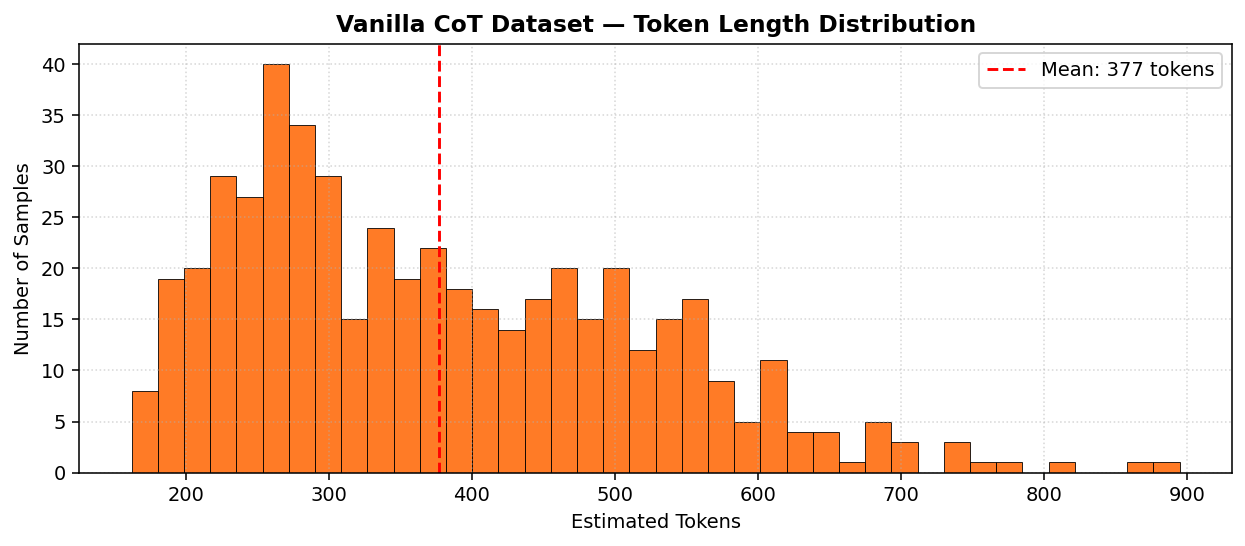

[OK] Token distribution plot saved to: results\vanilla_token_dist.png


In [4]:
vanilla_records = CoTDatasetBuilder.load_jsonl(vanilla_path)
token_counts = [r.get('token_count', 0) for r in vanilla_records]

fig_path = os.path.join(settings.storage.results_dir, "vanilla_token_dist.png")

plt.figure(figsize=(9, 4), dpi=140)
plt.hist(token_counts, bins=40, color='#FF6400', edgecolor='black', linewidth=0.5, alpha=0.85)
plt.axvline(vanilla_stats['avg_tokens'], color='red', linestyle='--', linewidth=1.5,
            label=f"Mean: {vanilla_stats['avg_tokens']} tokens")
plt.title('Vanilla CoT Dataset — Token Length Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Estimated Tokens', fontsize=10)
plt.ylabel('Number of Samples', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(fig_path, dpi=140)
plt.show()
print(f"[OK] Token distribution plot saved to: {fig_path}")

---
## 3. Sample Qualitative Inspection

Inspecting the first 2 reasoning traces to verify proper problem decomposition, `<thought>` encapsulation, and clean Python code.

In [5]:
for i, rec in enumerate(vanilla_records[:2]):
    print(f"\n{'='*70}")
    print(f"SAMPLE {i+1} | Task ID: {rec.get('task_id')} | Source: {rec.get('source')}")
    print(f"Tokens: {rec.get('token_count')} | Difficulty: {rec.get('difficulty_tag')}")
    print(f"\n--- PROMPT (first 250 chars) ---")
    print(rec.get('prompt', '')[:250].strip() + "...")
    print(f"\n--- REASONING TRACE & CODE (first 350 chars) ---")
    print(rec.get('response', '')[:350].strip() + "...")
print(f"{'='*70}")


SAMPLE 1 | Task ID: vanilla_cot_HumanEval_0_0 | Source: canonical_cot_synthesized
Tokens: 279 | Difficulty: standard

--- PROMPT (first 250 chars) ---
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0]...

--- REASONING TRACE & CODE (first 350 chars) ---
<thought>
1. Problem Decomposition & Objectives:
   - Target: from typing import List
   - Requirement: Analyze the function signature and handle edge cases systematically.

2. Algorithmic Strategy:
   - Parse the inputs and validate constraints.
   - Formulate the computation step-by-step to preserve time and space efficiency.
   - Verify terminat...

SAMPLE 2 | Task ID: vanilla_cot_HumanEval_1_1 | Source: canonical_cot_synthesized
Tokens: 360 | Difficulty: standard

--- PROMPT (first 250 chars) ---
from typing import List


def separate

---
## 4. Stage 3 Verification & Next Steps

The Vanilla CoT distillation dataset is saved and verified.  
You can now proceed to **`nb_04_qlora_training.ipynb`** to fine-tune **Model M2** using 4-bit NF4 QLoRA.

In [6]:
summary_df = pd.DataFrame([{
    "Dataset": "Vanilla CoT (Arm 2A)",
    "File": settings.distillation.vanilla_file,
    "Location": vanilla_path,
    "Total Samples": vanilla_stats['total_samples'],
    "Avg Tokens": vanilla_stats['avg_tokens'],
    "Target Model": "M2 (QLoRA Vanilla SFT)",
    "Status": "READY FOR TRAINING [OK]"
}])
print("\n[TRAIN] Stage 3 Distillation Dataset Construction Complete:")
summary_df


[TRAIN] Stage 3 Distillation Dataset Construction Complete:


,Dataset,File,Location,Total Samples,Avg Tokens,Target Model,Status
0,Vanilla CoT (Arm 2A),sft_positive_cot.jsonl,data/distillation\sft_positive_cot.jsonl,500,377,M2 (QLoRA Vanilla SFT),READY FOR TRAINING [OK]
